In [17]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Config

In [18]:
SHARED_DATASET_FILE = "../data/processed/cleaned_emotions_shared.csv"
SHARED_SPLIT_FILE   = "../data/splits/shared_split.json"

MODEL_NAME     = "bert-base-uncased"
MODEL_SAVE_DIR = "../models/bert_model"
PRED_FILE      = "../data/processed/bert_test_predictions.csv"
SUMMARY_FILE   = "../data/processed/bert_summary.csv"
DISPLAY_NAME   = "BERT"

MAX_LEN    = 64
BATCH_SIZE = 16
EPOCHS     = 5
LR         = 2e-5
PATIENCE   = 2

LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

total_start_time = time.time()

Using device: cpu


### Load Data

In [19]:
df = pd.read_csv(SHARED_DATASET_FILE)

with open(SHARED_SPLIT_FILE, "r", encoding="utf-8") as f:
    split_dict = json.load(f)

train_df = df[df["row_id"].isin(split_dict["train_ids"])].copy()
val_df   = df[df["row_id"].isin(split_dict["val_ids"])].copy()
test_df  = df[df["row_id"].isin(split_dict["test_ids"])].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

Train: (1512, 3)
Val  : (324, 3)
Test : (324, 3)

Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64


### Label Encoding

In [20]:
label_encoder = LabelEncoder()
label_encoder.fit(LABELS)

y_train = label_encoder.transform(train_df["label"])
y_val   = label_encoder.transform(val_df["label"])
y_test  = label_encoder.transform(test_df["label"])

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Number of classes: 6


### Tokenizer & Dataset

In [21]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(train_df["text"].tolist(), y_train, tokenizer, MAX_LEN)
val_dataset   = EmotionDataset(val_df["text"].tolist(),   y_val,   tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(test_df["text"].tolist(),  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 95
Val batches   : 21
Test batches  : 21


### Model

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes)
model = model.to(device)
print(f"Model   : {MODEL_NAME}")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8303.90it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Model   : bert-base-uncased
Params  : 109,486,854


### Train

In [23]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss    = float("inf")
patience_counter = 0

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc = eval_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS}  |  Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        model.save_pretrained(MODEL_SAVE_DIR)
        tokenizer.save_pretrained(MODEL_SAVE_DIR)
        print("  -> Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

train_elapsed = time.time() - train_start
print(f"\nTraining time: {train_elapsed:.2f} seconds")

Epoch 1/5  |  Train Loss: 1.4446  Acc: 0.4769  |  Val Loss: 0.8218  Acc: 0.8241


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.69it/s]


  -> Best model saved
Epoch 2/5  |  Train Loss: 0.4854  Acc: 0.9054  |  Val Loss: 0.2728  Acc: 0.9290


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.71it/s]


  -> Best model saved
Epoch 3/5  |  Train Loss: 0.1869  Acc: 0.9577  |  Val Loss: 0.2153  Acc: 0.9321


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.67it/s]


  -> Best model saved
Epoch 4/5  |  Train Loss: 0.0859  Acc: 0.9815  |  Val Loss: 0.2118  Acc: 0.9383


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.39it/s]


  -> Best model saved
Epoch 5/5  |  Train Loss: 0.0423  Acc: 0.9954  |  Val Loss: 0.2170  Acc: 0.9383

Training time: 1089.88 seconds


### Evaluate

In [24]:
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
best_model = best_model.to(device)
best_model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        preds   = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs        = np.array(all_probs)
test_pred_labels = label_encoder.inverse_transform(all_preds)
test_true_labels = label_encoder.inverse_transform(y_test)

acc               = accuracy_score(test_true_labels, test_pred_labels)
f1_macro          = f1_score(test_true_labels, test_pred_labels, average="macro")
f1_weighted       = f1_score(test_true_labels, test_pred_labels, average="weighted")
precision_macro   = precision_score(test_true_labels, test_pred_labels, average="macro",    zero_division=0)
precision_weighted = precision_score(test_true_labels, test_pred_labels, average="weighted", zero_division=0)

print(f"\n===== {DISPLAY_NAME} RESULT =====")
print("Accuracy          :", acc)
print("F1 Macro          :", f1_macro)
print("F1 Weighted       :", f1_weighted)
print("Precision Macro   :", precision_macro)
print("Precision Weighted:", precision_weighted)
print("\nClassification Report:")
print(classification_report(test_true_labels, test_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(test_true_labels, test_pred_labels, labels=LABELS))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5634.98it/s]



===== BERT RESULT =====
Accuracy          : 0.9320987654320988
F1 Macro          : 0.9423841610687141
F1 Weighted       : 0.9316714381602131
Precision Macro   : 0.9404023157128059
Precision Weighted: 0.9322065298880622

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      1.00      0.98        49
     disgust       0.95      0.88      0.91        64
        fear       0.89      0.92      0.90        60
       happy       1.00      1.00      1.00        35
     neutral       0.89      0.88      0.89        75
         sad       0.95      1.00      0.98        41

    accuracy                           0.93       324
   macro avg       0.94      0.95      0.94       324
weighted avg       0.93      0.93      0.93       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 2 56  2  0  3  1]
 [ 0  0 55  0  5  0]
 [ 0  0  0 35  0  0]
 [ 0  3  5  0 66  1]
 [ 0  0  0  0  0 41]]


### Save

In [25]:
pred_col       = f"{DISPLAY_NAME.lower()}_pred"
confidence_col = f"{DISPLAY_NAME.lower()}_confidence"

pred_df = test_df[["row_id", "text", "label"]].copy().reset_index(drop=True)
pred_df[pred_col]       = test_pred_labels
pred_df[confidence_col] = all_probs.max(axis=1)
pred_df.to_csv(PRED_FILE, index=False, encoding="utf-8-sig")

summary_df = pd.DataFrame([{
    "Model":              DISPLAY_NAME,
    "Accuracy":           acc,
    "F1_Macro":           f1_macro,
    "F1_Weighted":        f1_weighted,
    "Train_Time_Seconds": round(train_elapsed, 4),
    "Num_Classes":        num_classes
}])
summary_df.to_csv(SUMMARY_FILE, index=False, encoding="utf-8-sig")

total_elapsed = time.time() - total_start_time

print("\n===== Summary =====")
print(summary_df)
print(f"\nSaved:")
print("-", PRED_FILE)
print("-", SUMMARY_FILE)
print(f"\nTotal {DISPLAY_NAME} pipeline time: {total_elapsed:.2f} seconds")
print("Done")


===== Summary =====
  Model  Accuracy  F1_Macro  F1_Weighted  Train_Time_Seconds  Num_Classes
0  BERT  0.932099  0.942384     0.931671           1089.8849            6

Saved:
- ../data/processed/bert_test_predictions.csv
- ../data/processed/bert_summary.csv

Total BERT pipeline time: 1103.44 seconds
Done


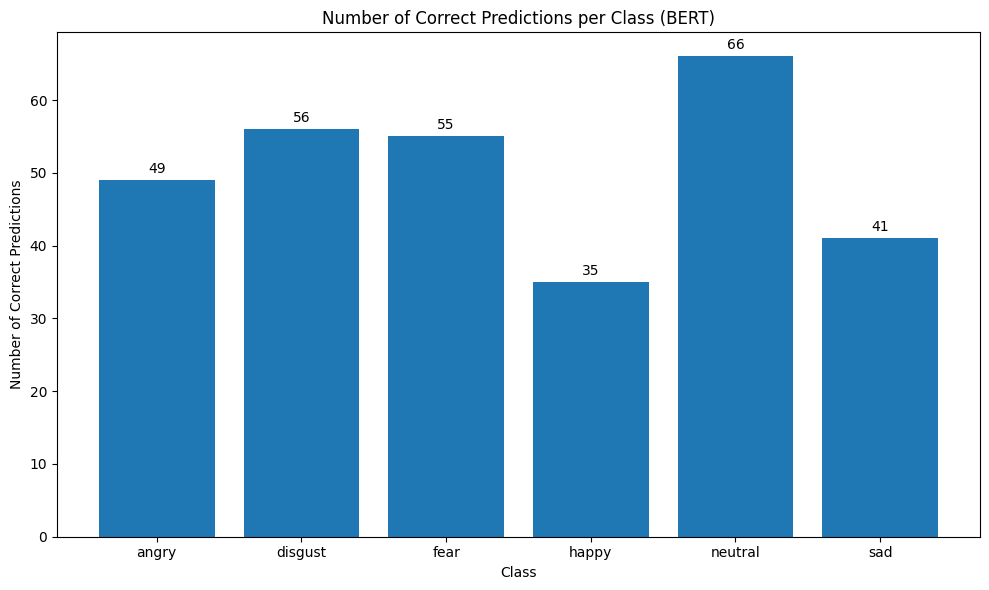

In [26]:
correct_counts = []
for label in LABELS:
    count = ((pred_df["label"] == label) & (pred_df[pred_col] == label)).sum()
    correct_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(LABELS, correct_counts, label=DISPLAY_NAME)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Correct Predictions")
ax.set_title(f"Number of Correct Predictions per Class ({DISPLAY_NAME})")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()


BERT Confusion Matrix


,angry,disgust,fear,happy,neutral,sad
angry,49,0,0,0,0,0
disgust,2,56,2,0,3,1
fear,0,0,55,0,5,0
happy,0,0,0,35,0,0
neutral,0,3,5,0,66,1
sad,0,0,0,0,0,41


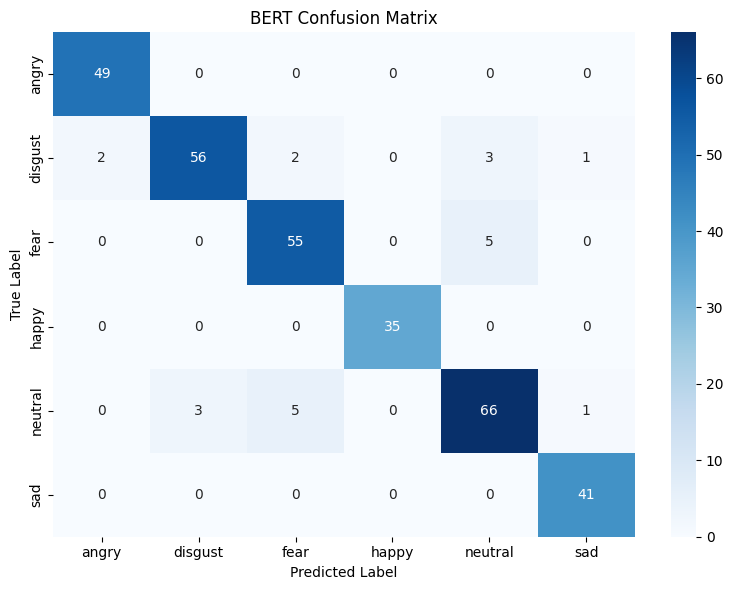

In [27]:
cm    = confusion_matrix(pred_df["label"], pred_df[pred_col], labels=LABELS)
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

print("\n" + "=" * 60)
print(f"{DISPLAY_NAME} Confusion Matrix")
print("=" * 60)
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"{DISPLAY_NAME} Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

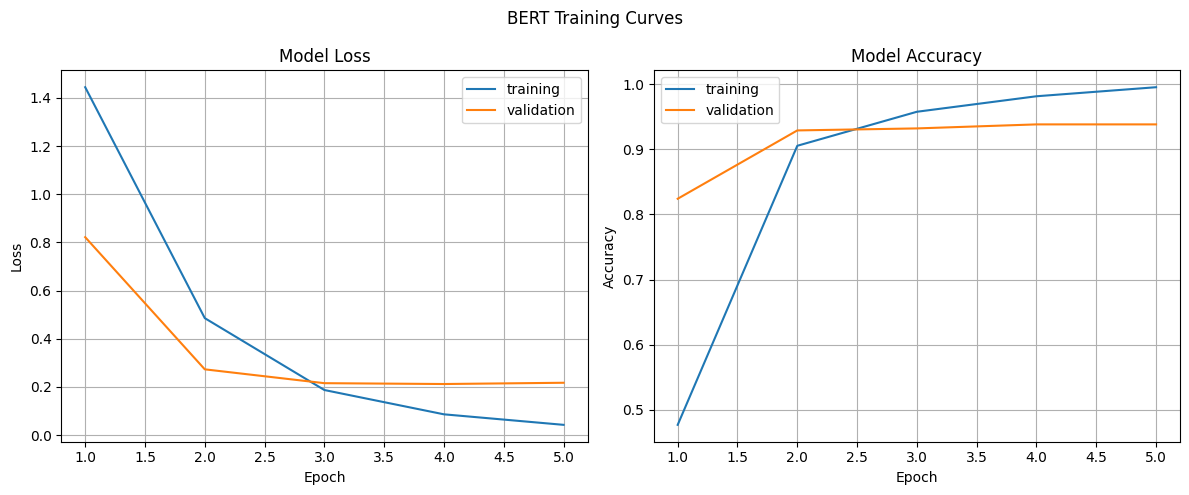

In [28]:
train_loss   = history["train_loss"]
val_loss     = history["val_loss"]
train_acc    = history["train_acc"]
val_acc      = history["val_acc"]
epochs_range = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, train_loss, label="training")
axes[0].plot(epochs_range, val_loss,   label="validation")
axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_acc, label="training")
axes[1].plot(epochs_range, val_acc,   label="validation")
axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"{DISPLAY_NAME} Training Curves")
plt.tight_layout()
plt.show()

In [29]:
final_train_acc  = train_acc[-1]
final_val_acc    = val_acc[-1]
final_train_loss = train_loss[-1]
final_val_loss   = val_loss[-1]

acc_gap  = final_train_acc  - final_val_acc
loss_gap = final_val_loss   - final_train_loss

print(f"===== {DISPLAY_NAME} Overfitting Check =====")
print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Accuracy Gap              : {acc_gap:.4f}")
print(f"\nFinal Training Loss       : {final_train_loss:.4f}")
print(f"Final Validation Loss     : {final_val_loss:.4f}")
print(f"Loss Gap                  : {loss_gap:.4f}")

if acc_gap > 0.10 and loss_gap > 0:
    print("\nResult: มีโอกาส Overfitting")
elif final_train_acc < 0.70 and final_val_acc < 0.70:
    print("\nResult: มีโอกาส Underfitting")
else:
    print("\nResult: ยังไม่เห็น Overfitting ชัดเจน")

===== BERT Overfitting Check =====
Final Training Accuracy   : 0.9954
Final Validation Accuracy : 0.9383
Accuracy Gap              : 0.0571

Final Training Loss       : 0.0423
Final Validation Loss     : 0.2170
Loss Gap                  : 0.1748

Result: ยังไม่เห็น Overfitting ชัดเจน
